In [1]:
import json
import random
import matplotlib.pyplot as plt
import torch
from tqdm import tqdm
from collections import Counter, defaultdict
import pandas as pd
import seaborn as sns
import torch
import matplotlib as mpl

def get_text_index(text, sub_test_sen_to_ids):
    index = list(sub_test_sen_to_ids.keys()).index(text)
    return index

In [2]:
def retrieval_enhance_v3_visual(cfg):
    '''

    :param cfg:
    :return:
    '''
    sub_test_sen_to_ids = json.load(open('../combine/data/sub_test_sen_to_ids_300*5.json', 'r', encoding='utf-8'))
    test_data_11 = json.load(open('../retrieval/data/test_data_11.json', 'r', encoding='utf-8'))
    test_img_ids = json.load(open('../encoder/data/test_img_ids.json', 'r', encoding='utf-8'))

    text_to_enhanced = json.load(open('../enhance/data/text_to_enhanced_list.json', 'r', encoding='utf-8'))

    text_enhance_to_flag = json.load(open('../enhance/data/text_enhance_to_flag.json', 'r', encoding='utf-8'))

    topk_num = cfg['topk_num']

    for name in model_name_list[3:]:
        fload_recall_list = []
        print(name)
        fload_text_to_sim = []
        for flod_i, test_data in enumerate(test_data_11):
            test_data_index_list = [get_text_index(text, sub_test_sen_to_ids) for text in test_data]
            image_features = torch.load('../encoder/data/image_features_{}.pt'.format(name),
                                        map_location=torch.device('cpu'))
            image_features = torch.stack(image_features).view(1000, -1)

            text_features = torch.load('../encoder/data/enhanced_text_features_{}.pt'.format(name),
                                       map_location=torch.device('cpu')) # list

            raw_text_features = torch.load('../encoder/data/raw_text_features_{}.pt'.format(name), map_location=torch.device('cpu'))
            raw_text_features /= raw_text_features.norm(dim=-1, keepdim=True)


            image_features /= image_features.norm(dim=-1, keepdim=True)

            recall_list = []
            text_to_sim = {}
            for i, text in enumerate(test_data):
                enhance_list = text_to_enhanced[text]
                type = sub_test_sen_to_ids[text]['type']

                 # check
                # new_enhance_index_list = [n_i for n_i, enhance_text in enumerate(enhance_list) if text_enhance_to_flag[text][enhance_text] == 1] # 保留的enhance_text的索引
                #
                # index = get_text_index(text, sub_test_sen_to_ids)
                # enhance_text_features = torch.cat([text_features[index][new_enhance_index_list], raw_text_features[index].view(1, -1)], 0)

                # no check
                index = get_text_index(text, text_to_enhanced)
                enhance_text_features = torch.cat([text_features[index], raw_text_features[index].view(1, -1)], 0)

                enhance_text_features /= enhance_text_features.norm(dim=-1, keepdim=True)
                similarity = (100.0 * enhance_text_features @ image_features.T).softmax(dim=-1)

                true_ids = sub_test_sen_to_ids[text]['images']
                true_ids_new = [img_id for img_id in true_ids if img_id in test_img_ids]
                true_ids = true_ids_new

                img_to_sim = defaultdict(list)

                first_reacall_img_index = []
                for enhance_i in range(enhance_text_features.shape[0]):
                    values, pre_indexes = similarity[enhance_i].topk(topk_num * 2)
                    for values, j in zip(values, pre_indexes):
                        pre_id = test_img_ids[j]
                        first_reacall_img_index.append(j.item())
                first_reacall_img_index = list(set(first_reacall_img_index))

                sub_img_features = image_features[first_reacall_img_index]
                similarity = (100.0 * enhance_text_features @ sub_img_features.T).softmax(dim=-1)

                text_to_sim[text] = similarity

                counter = Counter()
                for enhance_i in range(enhance_text_features.shape[0]):
                    values, pre_indexes = similarity[enhance_i].topk(topk_num + 5)
                    pre_ids = [test_img_ids[first_reacall_img_index[j]] for j in pre_indexes]
                    counter.update(pre_ids)
                pre_ids = [img_id for (img_id, _) in counter.most_common(topk_num)]

                r = 0
                for true_id in true_ids:
                    if true_id in pre_ids:
                        r += 1
                recall_list.append(r / min(len(true_ids), topk_num))

            recall = sum(recall_list) / len(recall_list)
            fload_recall_list.append(recall)
            fload_text_to_sim.append(text_to_sim)
            print('\tflod [{flod_i}], recall [{recall}]'.format(
                flod_i=flod_i,
                model=name,
                recall=recall
            ))

        print('model [{model}], recall [{recall}]'.format(
            model=name,
            recall=sum(fload_recall_list) / len(fload_recall_list)
        ))
        break
    return text_to_enhanced, fload_text_to_sim, test_data_11, sub_test_sen_to_ids, test_img_ids


In [3]:
def retrieval_enhance_v1_visual(cfg):
    '''
    Counter，原query
    :param cfg:
    :return:
    '''
    model_name_list = ['align-base', 'clipseg-rd64-refined', 'clip-vit-base-patch32', 'groupvit-gcc-yfcc']
    sub_test_sen_to_ids = json.load(open('../combine/data/sub_test_sen_to_ids_300*5.json', 'r', encoding='utf-8'))
    test_data_11 = json.load(open('../retrieval/data/test_data_11.json', 'r', encoding='utf-8'))
    test_img_ids = json.load(open('../encoder/data/test_img_ids.json', 'r', encoding='utf-8'))

    text_to_enhanced = json.load(open('../enhance/data/text_to_enhanced_list.json', 'r', encoding='utf-8'))

    topk_num = cfg['topk_num']

    for name in model_name_list[3:]:
        fload_recall_list = []
        print(name)
        fload_text_to_sim = []
        for flod_i, test_data in enumerate(test_data_11):
            test_data_index_list = [get_text_index(text, sub_test_sen_to_ids) for text in test_data]
            image_features = torch.load('../encoder/data/image_features_{}.pt'.format(name),
                                        map_location=torch.device('cpu'))
            image_features = torch.stack(image_features).view(1000, -1)

            text_features = torch.load('../encoder/data/enhanced_text_features_{}.pt'.format(name),
                                       map_location=torch.device('cpu')) # list

            raw_text_features = torch.load('../encoder/data/raw_text_features_{}.pt'.format(name),
                                           map_location=torch.device('cpu'))
            raw_text_features /= raw_text_features.norm(dim=-1, keepdim=True)

            image_features /= image_features.norm(dim=-1, keepdim=True)

            recall_list = []
            text_to_sim = {}
            for i, text in enumerate(test_data):
                enhance_list = text_to_enhanced[text]
                type = sub_test_sen_to_ids[text]['type']

                index = get_text_index(text, sub_test_sen_to_ids)
                enhance_text_features = torch.cat([text_features[index], raw_text_features[index].view(1, -1)], 0)

                enhance_text_features /= enhance_text_features.norm(dim=-1, keepdim=True)
                similarity = (100.0 * enhance_text_features @ image_features.T).softmax(dim=-1)

                text_to_sim[text] = similarity

                true_ids = sub_test_sen_to_ids[text]['images']
                true_ids_new = [img_id for img_id in true_ids if img_id in test_img_ids]
                true_ids = true_ids_new
                counter = Counter()
                for enhance_i in range(enhance_text_features.shape[0]):
                    values, pre_indexes = similarity[enhance_i].topk(topk_num)
                    pre_ids = [test_img_ids[j] for j in pre_indexes]
                    counter.update(pre_ids)
                pre_ids = [img_id for (img_id, _) in counter.most_common(topk_num)]
                r = 0
                for true_id in true_ids:
                    if true_id in pre_ids:
                        r += 1
                recall_list.append(r / min(len(true_ids), topk_num))

            recall = sum(recall_list) / len(recall_list)
            fload_recall_list.append(recall)
            print('\tflod [{flod_i}], recall [{recall}]'.format(
                flod_i=flod_i,
                model=name,
                recall=recall
            ))
            fload_text_to_sim.append(text_to_sim)
        print('model [{model}], recall [{recall}]'.format(
            model=name,
            recall=sum(fload_recall_list) / len(fload_recall_list)
        ))

    return text_to_enhanced, fload_text_to_sim, test_data_11, sub_test_sen_to_ids, test_img_ids

In [7]:

cfg = {
    'topk_num': 10,
}
model_name_list = ['align-base', 'clipseg-rd64-refined', 'clip-vit-base-patch32', 'groupvit-gcc-yfcc']
text_to_enhanced, fload_text_to_sim, test_data_11, sub_test_sen_to_ids, test_img_ids = retrieval_enhance_v3_visual(cfg)

groupvit-gcc-yfcc
	flod [0], recall [0.5524814814814815]
	flod [1], recall [0.53115873015873]
	flod [2], recall [0.5352222222222224]
	flod [3], recall [0.5602380952380953]
	flod [4], recall [0.5776666666666667]
	flod [5], recall [0.5651111111111112]
	flod [6], recall [0.39857142857142863]
	flod [7], recall [0.6032777777777777]
	flod [8], recall [0.5417037037037036]
	flod [9], recall [0.5953703703703704]
	flod [10], recall [0.5140185185185184]
model [groupvit-gcc-yfcc], recall [0.5431654641654642]


In [6]:
flod_i = 0
index = 97

test_data = test_data_11[flod_i]
text_to_sim = fload_text_to_sim[flod_i]
text = test_data[index]
ture_ids = sub_test_sen_to_ids[text]['images']
enhance_list = text_to_enhanced[text]

In [7]:
ture_ids, text

(['6315352509'], 'this race car')

In [8]:
sim = text_to_sim[text]
raw_sim = sim[0] # 原query相似度

In [9]:
topK_img_index= torch.topk(raw_sim, 10)[1].tolist()
topK_img_ids = [test_img_ids[i] for i in topK_img_index]

In [10]:
topK_sim = sim[:, topK_img_index].softmax(dim=-1).tolist()
x_index = [i+'**' if i in ture_ids else i for i in topK_img_ids]
x_index

['1181708011',
 '289639811',
 '1417941060',
 '3119887967',
 '3522989916',
 '1453366750',
 '4401136784',
 '6315352509**',
 '8138745455',
 '3149038044']

In [11]:
df = pd.DataFrame(columns=x_index, index=enhance_list + [text], data=topK_sim)

In [12]:
import random


new_col_name = x_index.copy()
random.seed(20231016)
random.shuffle(new_col_name)

In [13]:
df = df[new_col_name]
df

,3119887967,1417941060,3149038044,1181708011,1453366750,8138745455,289639811,4401136784,3522989916,6315352509**
It has a sleek and aerodynamic body.,0.090046,0.090248,0.088086,0.192761,0.088629,0.088112,0.096358,0.088262,0.089240,0.088259
The car has large tires and a low profile.,0.089735,0.089731,0.090382,0.166633,0.098711,0.090784,0.100322,0.090410,0.093859,0.089434
The body is painted in a bright and bold color.,0.092841,0.092328,0.096530,0.147101,0.092464,0.092977,0.096742,0.103738,0.092453,0.092824
The car has a large and powerful engine.,0.093736,0.093241,0.105323,0.108674,0.120866,0.097386,0.093808,0.101794,0.092960,0.092212
The wheels are made of lightweight aluminum.,0.086282,0.086292,0.086516,0.222124,0.086199,0.086449,0.086161,0.087624,0.086174,0.086179
The car has a futuristic and aggressive design.,0.090455,0.096829,0.091685,0.096308,0.091472,0.090657,0.156922,0.090299,0.104800,0.090572
The body is made of carbon fiber.,0.091508,0.115088,0.113392,0.094739,0.126471,0.093171,0.091291,0.091702,0.091333,0.091305
The car has a distinctive and recognizable logo.,0.093347,0.092747,0.091861,0.135982,0.092831,0.092501,0.097938,0.116187,0.092591,0.094015
The car has a sharp and pointed nose.,0.088073,0.087099,0.087119,0.206806,0.090283,0.087963,0.089283,0.087157,0.088992,0.087224
. The car has a large and wing-like spoiler.,0.100000,0.093157,0.089106,0.166976,0.093475,0.091519,0.097042,0.089074,0.090627,0.089023


<AxesSubplot: >

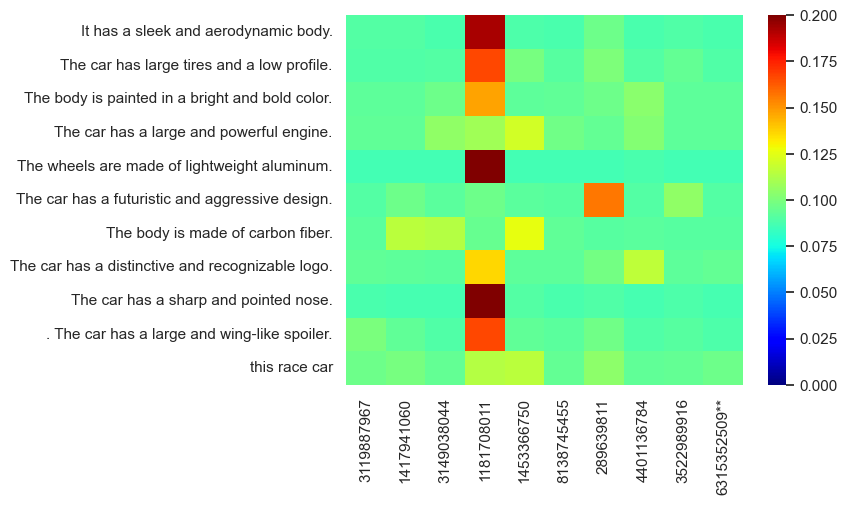

In [14]:
sns.set(font_scale=1)
sns.heatmap(data=df,vmin=0,vmax=0.2,  cmap=mpl.colormaps['jet'])

In [15]:
# 找到有正确图片的
for i in range(len(test_data_11)):
    test_data = test_data_11[i]
    text_to_sim = fload_text_to_sim[i]
    for j in range(len(test_data)):
        text = test_data[j]
        ture_ids = sub_test_sen_to_ids[text]['images']
        sim = text_to_sim[text]
        raw_sim = sim[0] # 原query相似度
        topK_img_index= torch.topk(raw_sim, 10)[1].tolist()
        topK_img_ids = [test_img_ids[i] for i in topK_img_index]

        for img_id in topK_img_ids:
            if img_id in ture_ids:
                print(i, j)
                break


0 54
0 88
0 97
0 125
1 41
2 128
2 134
2 135
2 138
3 129
4 144
4 148
5 61
5 122
6 41
6 135
6 147
7 58
7 96
7 125
7 131
7 136
8 110
8 128
9 100
9 123
10 20
10 26
10 45


In [6]:
# 整合
# 0,125
# 2,128; 2,124 ; 2,138; 4,144; 7, 131 稍微差一点
# 3,129
# 4, 148
# 9,123 !!!!
flod_i = 0
index = 125

test_data = test_data_11[flod_i]
text_to_sim = fload_text_to_sim[flod_i]
text = test_data[index]
ture_ids = sub_test_sen_to_ids[text]['images']
enhance_list = text_to_enhanced[text]

sim = text_to_sim[text]
raw_sim = sim[0] # 原query相似度

topK_img_index= torch.topk(raw_sim, 100)[1].tolist()
topK_img_ids = [test_img_ids[i] for i in topK_img_index]

topK_sim = sim[:, topK_img_index].softmax(dim=-1).tolist()
x_index = [i+'**' if i in ture_ids else i for i in topK_img_ids]

df = pd.DataFrame(columns=x_index, index=enhance_list + ['[{}]'.format(text)], data=topK_sim)



new_col_name = x_index.copy()
random.seed(20231016)
random.shuffle(new_col_name)

df = df[new_col_name]

RuntimeError: selected index k out of range

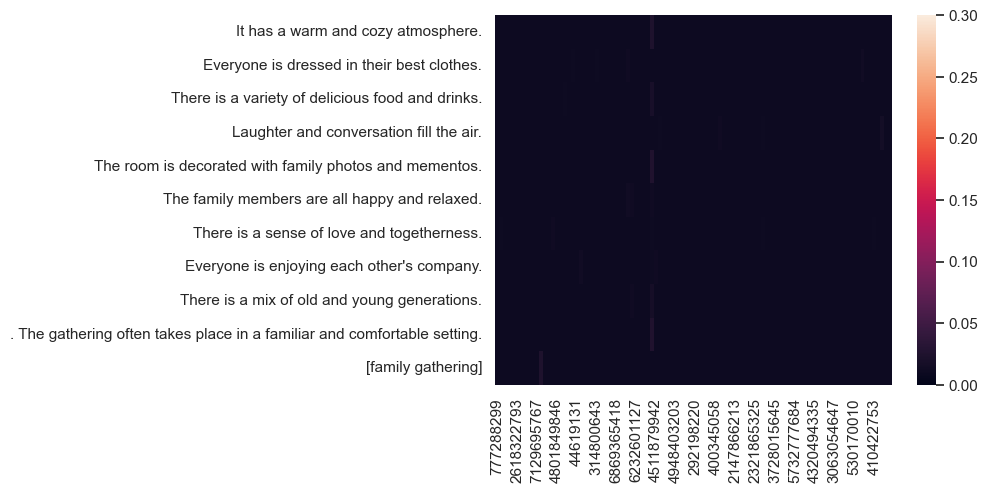

In [54]:
sns.set(font_scale=1)
sns.heatmap(data=df,vmin=0,vmax=0.3)
plt.savefig(f'data/visual_fold_{flod_i}-index_{index}'.format(flod_i=flod_i, index=index), dpi=600,bbox_inches = 'tight')

In [47]:
ture_ids

['455714074', '358355700', '4365035558']

In [12]:
topK_img_index= torch.topk(raw_sim, 111)[1].tolist()
topK_img_ids = [test_img_ids[i] for i in topK_img_index]

In [13]:
for i in topK_img_ids:
    if i in ture_ids:
        print(1)

1


In [11]:
raw_sim.shape

torch.Size([111])

## New

In [ ]:
def retrieval_enhance_v3_visual(cfg):
    '''

    :param cfg:
    :return:
    '''
    sub_test_sen_to_ids = json.load(open('../combine/data/sub_test_sen_to_ids_300*5.json', 'r', encoding='utf-8'))
    test_data_11 = json.load(open('../retrieval/data/test_data_11.json', 'r', encoding='utf-8'))
    test_img_ids = json.load(open('../encoder/data/test_img_ids.json', 'r', encoding='utf-8'))

    text_to_enhanced = json.load(open('../enhance/data/text_to_enhanced_list.json', 'r', encoding='utf-8'))

    text_enhance_to_flag = json.load(open('../enhance/data/text_enhance_to_flag.json', 'r', encoding='utf-8'))

    topk_num = cfg['topk_num']

    for name in model_name_list[3:]:
        fload_recall_list = []
        print(name)
        fload_text_to_sim = []
        for flod_i, test_data in enumerate(test_data_11):
            test_data_index_list = [get_text_index(text, sub_test_sen_to_ids) for text in test_data]
            image_features = torch.load('../encoder/data/image_features_{}.pt'.format(name),
                                        map_location=torch.device('cpu'))
            image_features = torch.stack(image_features).view(1000, -1)

            text_features = torch.load('../encoder/data/enhanced_text_features_{}.pt'.format(name),
                                       map_location=torch.device('cpu')) # list

            raw_text_features = torch.load('../encoder/data/raw_text_features_{}.pt'.format(name), map_location=torch.device('cpu'))
            raw_text_features /= raw_text_features.norm(dim=-1, keepdim=True)


            image_features /= image_features.norm(dim=-1, keepdim=True)

            recall_list = []
            text_to_sim = {}
            for i, text in enumerate(test_data):
                enhance_list = text_to_enhanced[text]
                type = sub_test_sen_to_ids[text]['type']

                 # check
                # new_enhance_index_list = [n_i for n_i, enhance_text in enumerate(enhance_list) if text_enhance_to_flag[text][enhance_text] == 1] # 保留的enhance_text的索引
                #
                # index = get_text_index(text, sub_test_sen_to_ids)
                # enhance_text_features = torch.cat([text_features[index][new_enhance_index_list], raw_text_features[index].view(1, -1)], 0)

                # no check
                index = get_text_index(text, text_to_enhanced)
                enhance_text_features = torch.cat([text_features[index], raw_text_features[index].view(1, -1)], 0)

                enhance_text_features /= enhance_text_features.norm(dim=-1, keepdim=True)
                similarity = (100.0 * enhance_text_features @ image_features.T).softmax(dim=-1)

                true_ids = sub_test_sen_to_ids[text]['images']
                true_ids_new = [img_id for img_id in true_ids if img_id in test_img_ids]
                true_ids = true_ids_new

                img_to_sim = defaultdict(list)

                first_reacall_img_index = []
                for enhance_i in range(enhance_text_features.shape[0]):
                    values, pre_indexes = similarity[enhance_i].topk(topk_num * 2)
                    for values, j in zip(values, pre_indexes):
                        pre_id = test_img_ids[j]
                        first_reacall_img_index.append(j.item())
                first_reacall_img_index = list(set(first_reacall_img_index))

                sub_img_features = image_features[first_reacall_img_index]
                similarity = (100.0 * enhance_text_features @ sub_img_features.T).softmax(dim=-1)

                text_to_sim[text] = similarity

                counter = Counter()
                for enhance_i in range(enhance_text_features.shape[0]):
                    values, pre_indexes = similarity[enhance_i].topk(topk_num + 5)
                    pre_ids = [test_img_ids[first_reacall_img_index[j]] for j in pre_indexes]
                    counter.update(pre_ids)
                pre_ids = [img_id for (img_id, _) in counter.most_common(topk_num)]

                r = 0
                for true_id in true_ids:
                    if true_id in pre_ids:
                        r += 1
                recall_list.append(r / min(len(true_ids), topk_num))

            recall = sum(recall_list) / len(recall_list)
            fload_recall_list.append(recall)
            fload_text_to_sim.append(text_to_sim)
            print('\tflod [{flod_i}], recall [{recall}]'.format(
                flod_i=flod_i,
                model=name,
                recall=recall
            ))

        print('model [{model}], recall [{recall}]'.format(
            model=name,
            recall=sum(fload_recall_list) / len(fload_recall_list)
        ))
        break
    return text_to_enhanced, fload_text_to_sim, test_data_11, sub_test_sen_to_ids, test_img_ids


In [19]:
import torch

In [14]:
raw_query = 'family gathering'
model_name = 'groupvit-gcc-yfcc'

In [20]:
text_to_enhanced = json.load(open('../enhance/data/text_to_enhanced_list.json', 'r', encoding='utf-8'))


image_features = torch.load('../encoder/data/image_features_{}.pt'.format(model_name),map_location=torch.device('cpu'))
image_features = torch.stack(image_features).view(1000, -1)
text_features = torch.load('../encoder/data/enhanced_text_features_{}.pt'.format(model_name),map_location=torch.device('cpu')) # list
raw_text_features = torch.load('../encoder/data/raw_text_features_{}.pt'.format(model_name), map_location=torch.device('cpu'))


raw_text_features /= raw_text_features.norm(dim=-1, keepdim=True)
image_features /= image_features.norm(dim=-1, keepdim=True)

In [28]:
true_ids = sub_test_sen_to_ids[raw_query]['images']
true_ids

['455714074', '358355700', '4365035558']

In [26]:
enhance_list = text_to_enhanced[raw_query]
enhance_list

['It has a warm and cozy atmosphere.',
 'Everyone is dressed in their best clothes.',
 'There is a variety of delicious food and drinks.',
 'Laughter and conversation fill the air.',
 'The room is decorated with family photos and mementos.',
 'The family members are all happy and relaxed.',
 'There is a sense of love and togetherness.',
 "Everyone is enjoying each other's company.",
 'There is a mix of old and young generations.',
 '. The gathering often takes place in a familiar and comfortable setting.']

In [21]:
index = get_text_index(text, text_to_enhanced)

In [22]:
feature = torch.cat([text_features[index], raw_text_features[index].view(1, -1)], 0)

In [23]:
similarity = (100.0 * feature @ image_features.T).softmax(dim=-1)

In [30]:
topk_num = 10

In [31]:
first_reacall_img_index = []
for enhance_i in range(feature.shape[0]):
    values, pre_indexes = similarity[enhance_i].topk(topk_num  * 2)
    for values, j in zip(values, pre_indexes):
        pre_id = test_img_ids[j]
        first_reacall_img_index.append(j.item())
first_reacall_img_index = list(set(first_reacall_img_index))

sub_img_features = image_features[first_reacall_img_index]
similarity = (100.0 * feature @ sub_img_features.T).softmax(dim=-1)

text_to_sim[text] = similarity

counter = Counter()
for enhance_i in range(feature.shape[0]):
    values, pre_indexes = similarity[enhance_i].topk(topk_num + 5)
    pre_ids = [test_img_ids[first_reacall_img_index[j]] for j in pre_indexes]
    counter.update(pre_ids)
pre_ids = [img_id for (img_id, _) in counter.most_common(topk_num)]

r = 0
for true_id in true_ids:
    if true_id in pre_ids:
        r += 1

In [32]:
r

1

In [33]:
pre_ids

['1378557186',
 '455714074',
 '3607969989',
 '1483574454',
 '3708748633',
 '19469520',
 '6901412',
 '2618322793',
 '2747436384',
 '7129695767']

In [35]:
true_ids

['455714074', '358355700', '4365035558']